# Single Subject Cached Prediction EDA

This notebook is focused on figure production and rapid iteration from cached all-genes model outputs.
Defaults:
- subject selection: representative (closest to GTEx cohort median)
- evaluation panel: HVG subset (stratified from all-genes fit caches)
- explicit subject override is supported.


In [29]:
from pathlib import Path
import sys
import importlib
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


In [30]:
import src.eval_utils.results_eda
importlib.reload(src.eval_utils.results_eda)
from src.eval_utils.results_eda import *


In [31]:
set_academic_style()

# Cache-reading config (models fit on all genes).
CACHE_GENE_SCOPE = 'allgenes'
PLAM_CACHE_DIRNAME = 'plam_rank3'  # auto | plam | plam_rank3 | plam_rank4 | plam_dynamicrank

def _resolve_plam_dir(cache_root: str, gene_scope: str, requested: str) -> str:
    req = str(requested)
    if req != 'auto':
        return req
    base = Path(cache_root) / gene_scope
    prefs = ['plam_dynamicrank', 'plam_rank4', 'plam_rank3', 'plam']
    for d in prefs:
        if (base / d).exists():
            return d
    return 'plam'

_plam_dir = _resolve_plam_dir('out/loro_subject_cache', CACHE_GENE_SCOPE, PLAM_CACHE_DIRNAME)

CFG = EDAConfig(
    csv_path='data/raw/gxp_samples.csv',
    hvg_path='data/raw/ahba_100hvg.txt',
    cache_root='out/loro_subject_cache',
    gene_scope=CACHE_GENE_SCOPE,
    plam_cache_dirname=_plam_dir,
)

print('using plam cache dir:', CFG.plam_cache_dirname)
CFG


using plam cache dir: plam_rank3


EDAConfig(csv_path='data/raw/gxp_samples.csv', hvg_path='data/raw/ahba_100hvg.txt', cache_root='out/loro_subject_cache', naive_cache_dirname='naive', dlam_cache_dirname='dlam', plam_cache_dirname='plam_rank3', gene_scope='allgenes', min_observed_parcels=5, combat_use_covariates=True)

## Subject Selection Controls

Priority order:
1. `SUBJECT_ID_OVERRIDE` if provided.
2. `SUBJECT_SELECT_MODE='representative'` (closest to GTEx cohort median in selected gene space).
3. model-based modes (`model_median`, `model_best`, `model_worst`).


In [ ]:
# Explicit override (e.g., 'GTEX-14ASI', 'GTEX-13OW8'). Set to None to use automatic selection.
SUBJECT_ID_OVERRIDE = 'GTEX-13OW8'
# representative | model_median | model_best | model_worst
SUBJECT_SELECT_MODE = 'representative'
# Used only for model_* modes
SUBJECT_MODEL = 'plam'   # naive | dlam | plam
SUBJECT_METRIC = 'pearson_r'  # pearson_r | rmse
# Representative-mode controls
REP_SPACE = 'harmonized'    # harmonized | raw
REP_MIN_COVERAGE = 5
REP_REQUIRE_COVERAGE = None  # e.g., 11 for full-coverage-only representative
# Plot/evaluation defaults
GENE_MODE = 'hvg'            # hvg | allgenes | custom
CUSTOM_GENE_LIST = None      # list[str] when GENE_MODE='custom'
LABEL_MODE = 'gtex'          # gtex | ahba | both
# PREPOST build scope for harmonization diagnostics (lighter default).
PREPOST_GENE_SCOPE = 'allgenes'   # hvg | allgenes

In [ ]:
# Fast subject resolution behavior:
# - explicit SUBJECT_ID_OVERRIDE resolves immediately (no PREPOST compute)
# - representative mode requires PREPOST and may take ~1-2 minutes to build
FORCE_REBUILD_PREPOST = False

PREPOST_CFG = EDAConfig(
    csv_path=CFG.csv_path,
    hvg_path=CFG.hvg_path,
    cache_root=CFG.cache_root,
    naive_cache_dirname=CFG.naive_cache_dirname,
    dlam_cache_dirname=CFG.dlam_cache_dirname,
    plam_cache_dirname=CFG.plam_cache_dirname,
    gene_scope=PREPOST_GENE_SCOPE,
    min_observed_parcels=CFG.min_observed_parcels,
    combat_use_covariates=CFG.combat_use_covariates,
)

if SUBJECT_ID_OVERRIDE is not None and str(SUBJECT_ID_OVERRIDE).strip():
    SUBJECT_ID, subject_selection_df = resolve_publication_subject(
        cfg=CFG,
        prepost=None,
        subject_id=SUBJECT_ID_OVERRIDE,
        mode=SUBJECT_SELECT_MODE,
        model=SUBJECT_MODEL,
        metric=SUBJECT_METRIC,
        gene_mode=GENE_MODE,
        gene_list=CUSTOM_GENE_LIST,
        space=REP_SPACE,
        min_coverage=REP_MIN_COVERAGE,
        require_coverage=REP_REQUIRE_COVERAGE,
    )
else:
    if FORCE_REBUILD_PREPOST or ('PREPOST' not in globals()) or (globals().get('_PREPOST_SCOPE') != PREPOST_CFG.gene_scope):
        PREPOST = prepare_pre_post_harmonization(PREPOST_CFG)
        _PREPOST_SCOPE = PREPOST_CFG.gene_scope
    SUBJECT_ID, subject_selection_df = resolve_publication_subject(
        cfg=CFG,
        prepost=PREPOST,
        subject_id=None,
        mode=SUBJECT_SELECT_MODE,
        model=SUBJECT_MODEL,
        metric=SUBJECT_METRIC,
        gene_mode=GENE_MODE,
        gene_list=CUSTOM_GENE_LIST,
        space=REP_SPACE,
        min_coverage=REP_MIN_COVERAGE,
        require_coverage=REP_REQUIRE_COVERAGE,
    )

print('selected subject:', SUBJECT_ID)
print('prepost gene scope:', PREPOST_CFG.gene_scope if 'PREPOST_CFG' in globals() else 'not-built')
display(subject_selection_df.head(12))


selected subject: GTEX-13OW8
prepost gene scope: allgenes


,subject,selection_mode
0,GTEX-13OW8,explicit_subject_id


## Matrix Diagnostics (Single Subject)

Rows: naive / DLAM / PLAM  
Columns: AHBA median harmonized, sparse GTEx, completed GTEx, residual.


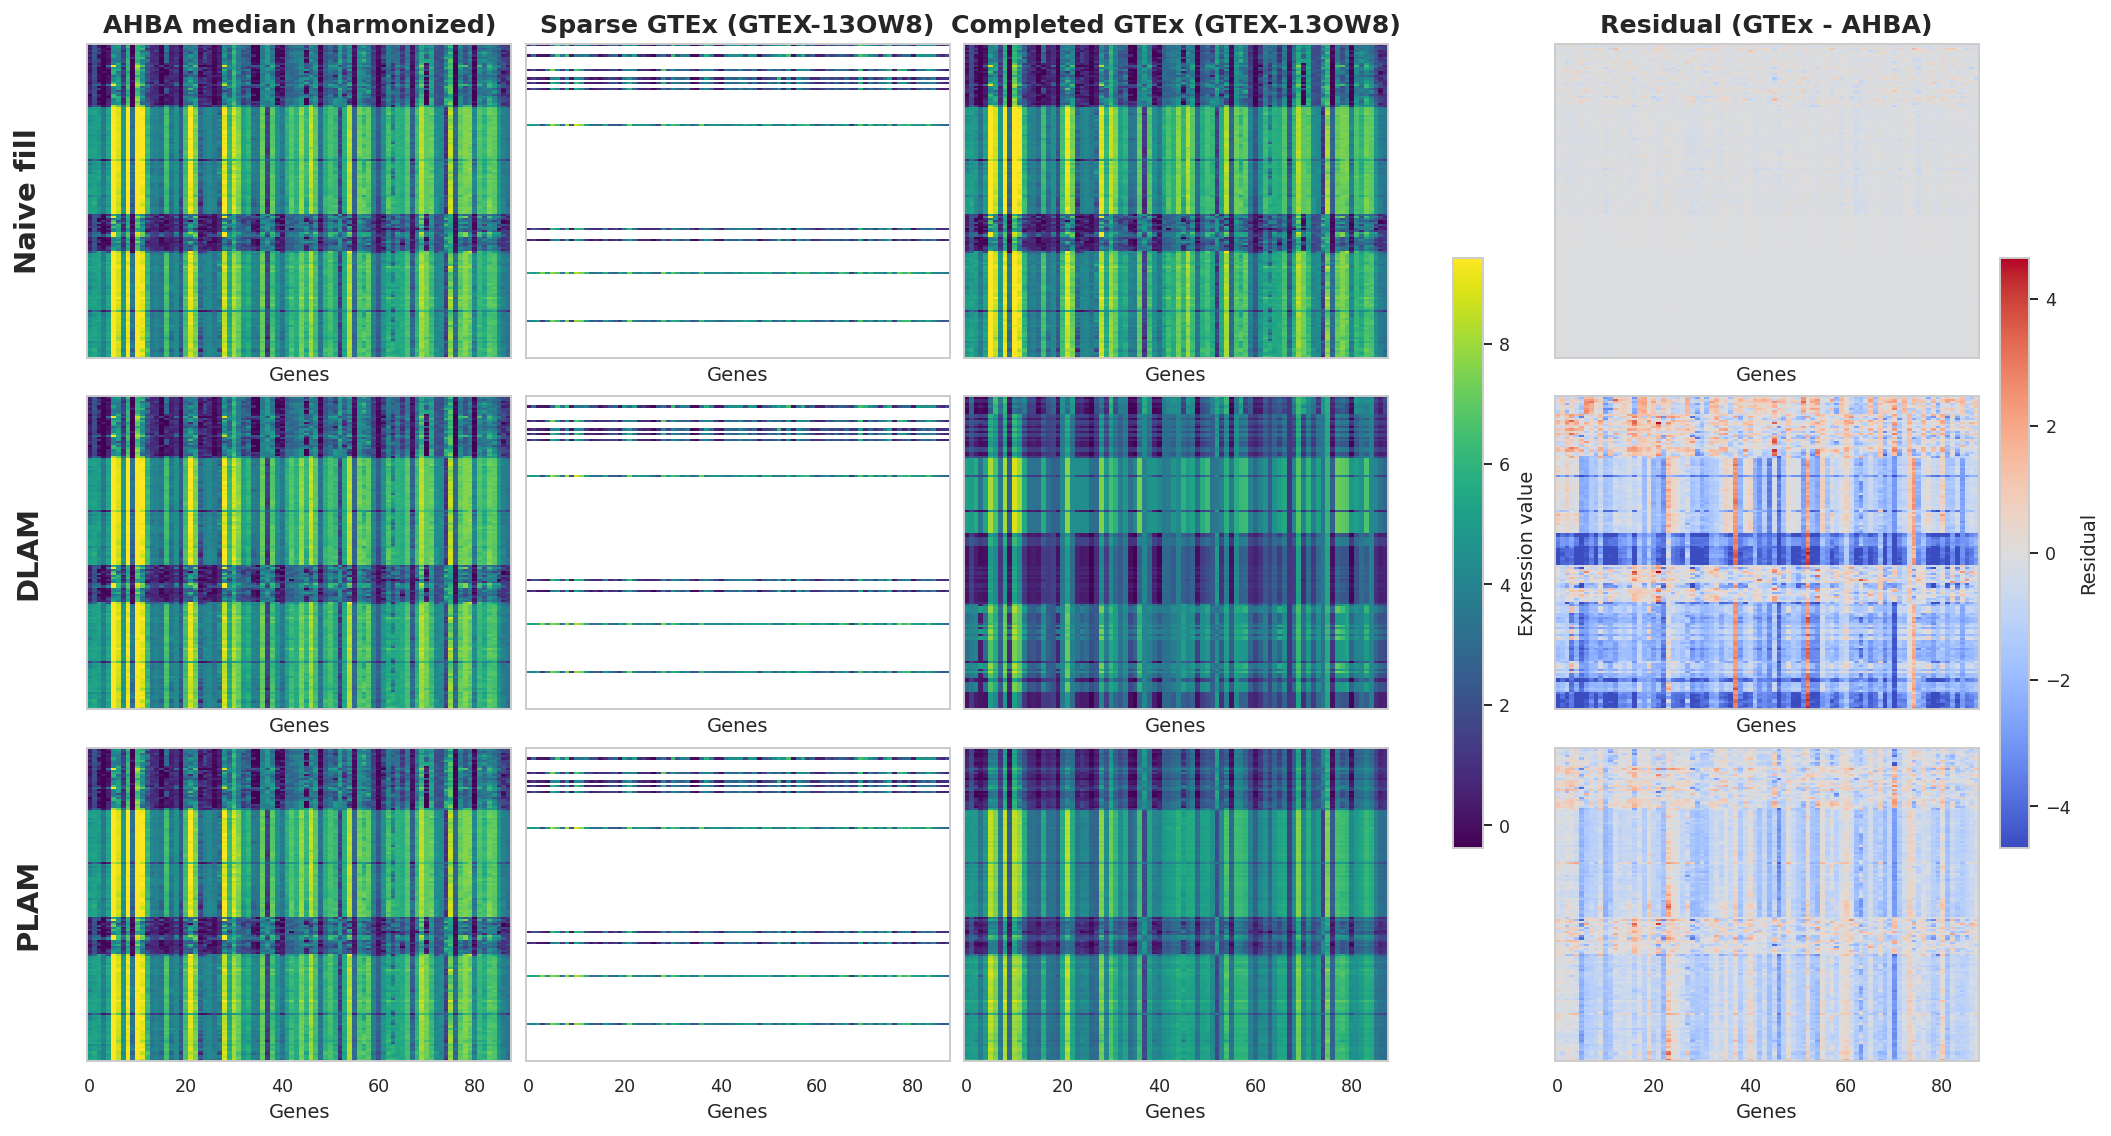

In [44]:
if 'PREPOST' not in globals():
    PREPOST = prepare_pre_post_harmonization(PREPOST_CFG)

MATRIX_OBSERVED_ONLY = False
MATRIX_RENDER_MAX_GENES = 100  # reduce render load for stability

fig, axes = plot_subject_model_matrix_panel(
    cfg=CFG,
    prepost=PREPOST,
    subject_id=SUBJECT_ID,
    gene_mode=GENE_MODE,
    gene_list=CUSTOM_GENE_LIST,
    label_mode=LABEL_MODE,
    observed_only=MATRIX_OBSERVED_ONLY,
    cmap='viridis',
    figsize=(15, 8),
    render_max_genes=MATRIX_RENDER_MAX_GENES,
)


## Alignment Scatter Panel (Observed + Model Predictions)

Panel 1 is observed GTEx vs AHBA. Panels 2-4 are naive/DLAM/PLAM predictions vs AHBA.


In [45]:
import src.eval_utils.results_eda
importlib.reload(src.eval_utils.results_eda)
from src.eval_utils.results_eda import *


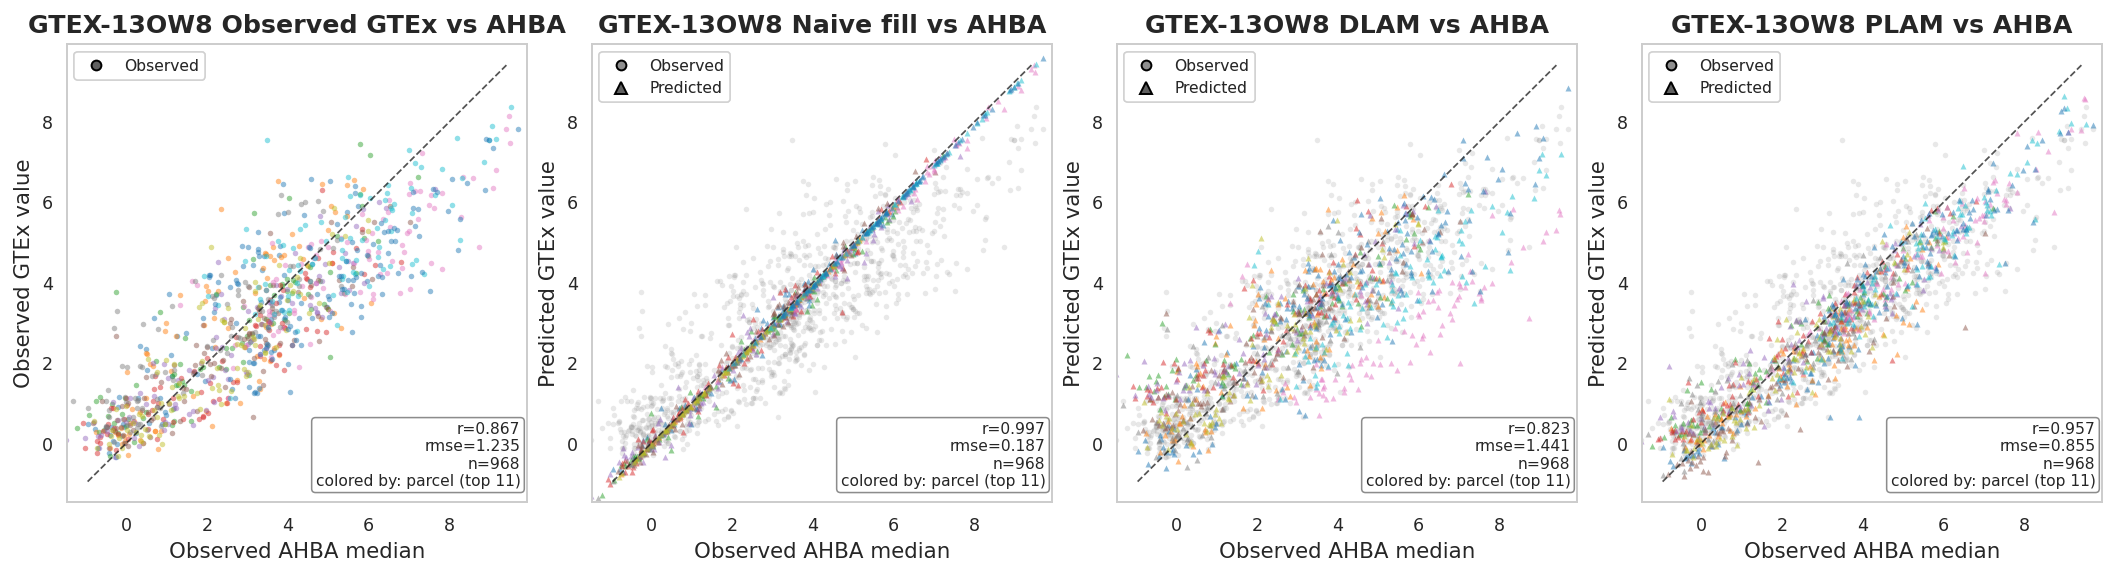

In [46]:
SCATTER_PARCELS = 'observed'    # observed | all
SCATTER_COLOR_BY = 'parcel'     # parcel | gene | none
SCATTER_TOP_N = 11
SCATTER_OVERLAY_OBSERVED = True

fig, axes = plot_subject_alignment_scatter_panel(
    cfg=CFG,
    prepost=PREPOST,
    subject_id=SUBJECT_ID,
    gene_mode=GENE_MODE,
    gene_list=CUSTOM_GENE_LIST,
    parcels=SCATTER_PARCELS,
    color_by=SCATTER_COLOR_BY,
    top_n=SCATTER_TOP_N,
    overlay_observed_in_predictions=SCATTER_OVERLAY_OBSERVED,
    figsize=(15, 4),
)


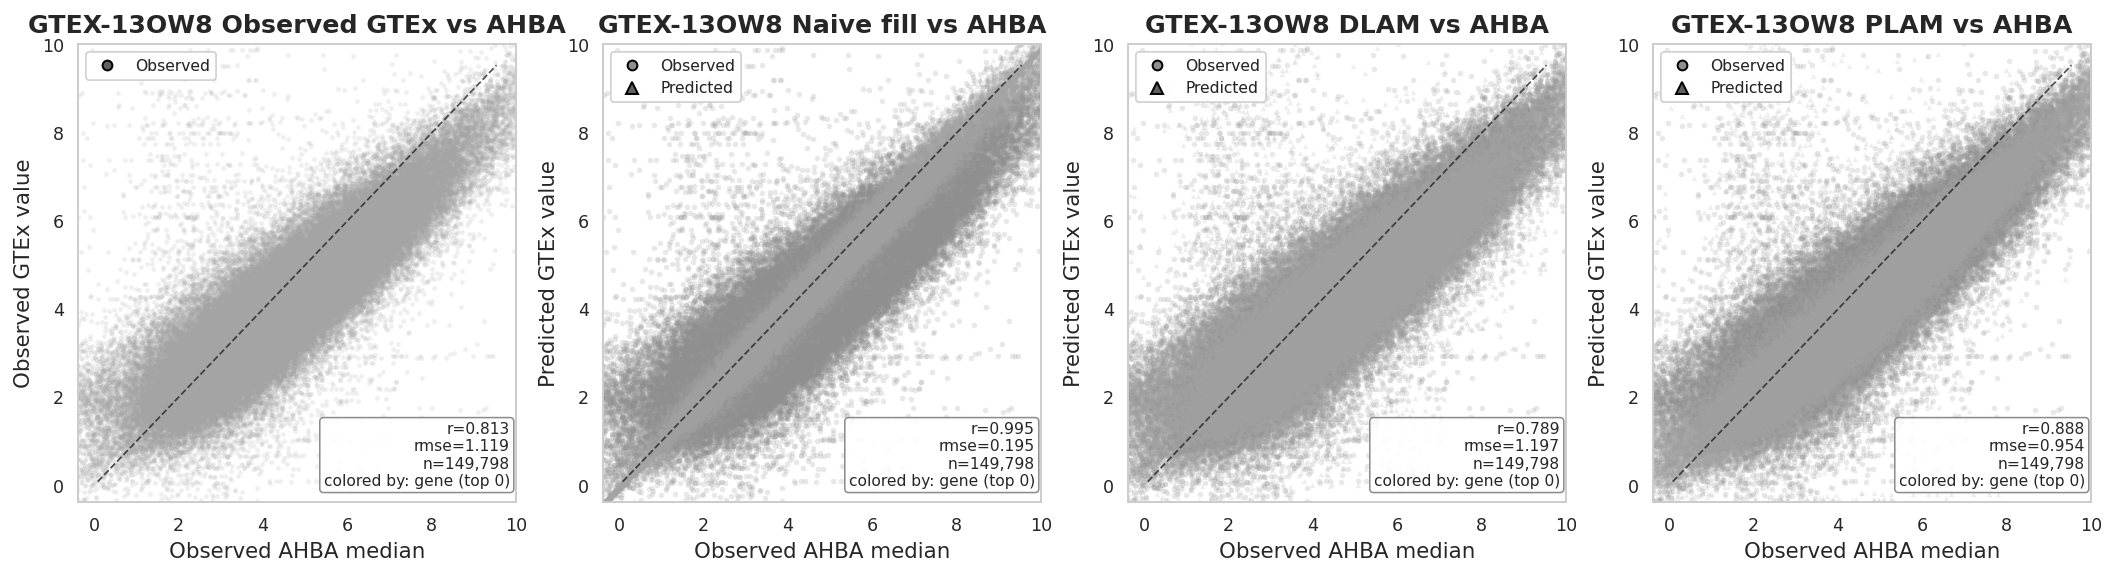

In [47]:
SCATTER_PARCELS = 'observed'    # observed | all
SCATTER_COLOR_BY = 'gene'     # parcel | gene | none
SCATTER_TOP_N = 0
SCATTER_OVERLAY_OBSERVED = True

fig, axes = plot_subject_alignment_scatter_panel(
    cfg=CFG,
    prepost=PREPOST,
    subject_id=SUBJECT_ID,
    gene_mode='allgenes',
    gene_list=CUSTOM_GENE_LIST,
    parcels=SCATTER_PARCELS,
    color_by=SCATTER_COLOR_BY,
    top_n=SCATTER_TOP_N,
    overlay_observed_in_predictions=SCATTER_OVERLAY_OBSERVED,
    figsize=(15, 4),
)


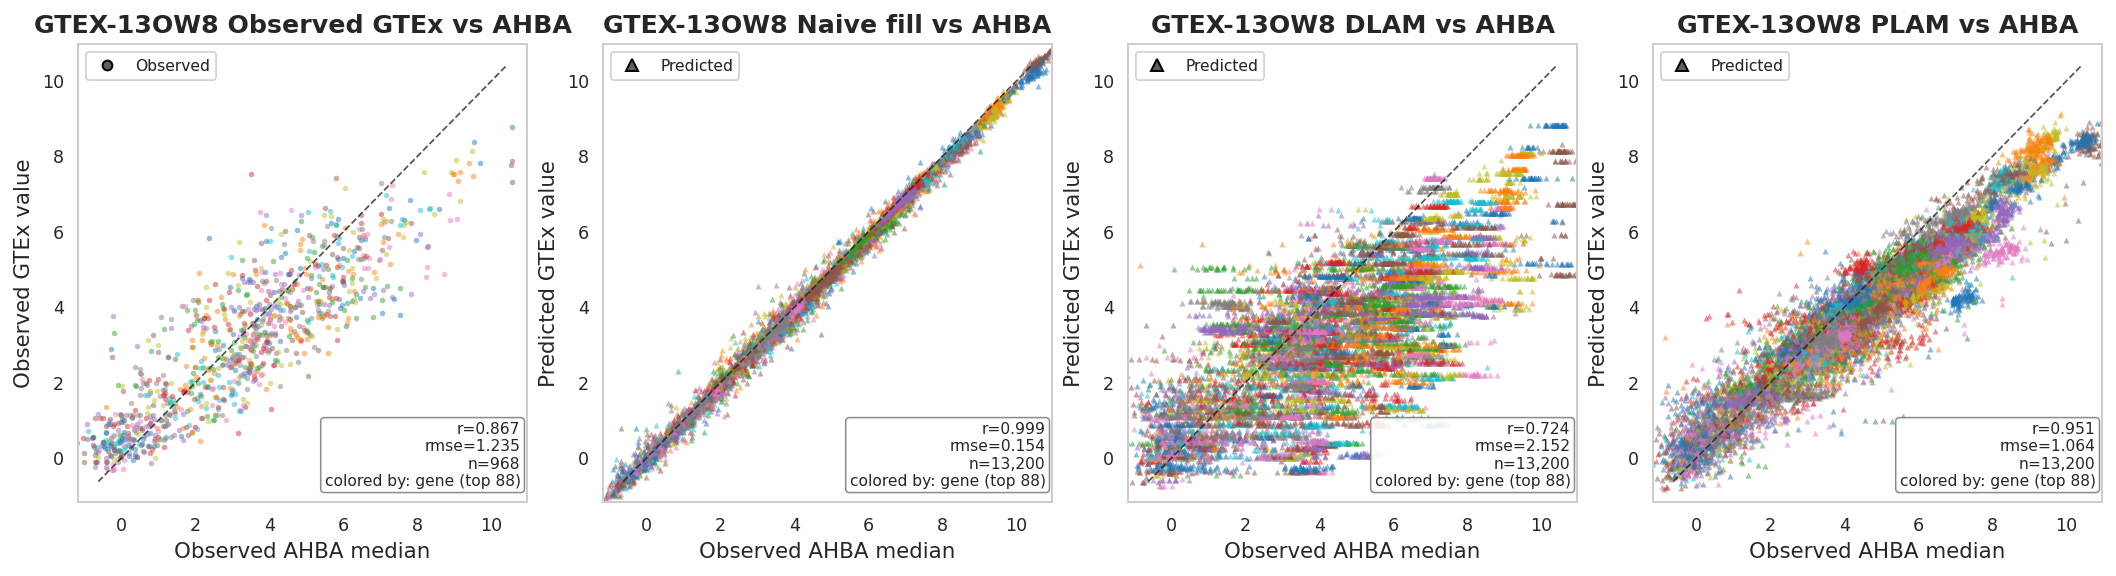

In [48]:
fig, axes = plot_subject_alignment_scatter_panel(
    cfg=CFG,
    prepost=PREPOST,
    subject_id=SUBJECT_ID,
    gene_mode=GENE_MODE,
    gene_list=CUSTOM_GENE_LIST,
    parcels='all',                     # <-- all atlas parcels
    color_by='gene',                 # or 'gene' / 'none'
    top_n=88,
    overlay_observed_in_predictions=False,
    figsize=(15, 4),
)


## Performance Scatter Triplet (Held-Out Truth)

This mirrors the LORO performance scatter view for the same subject.


In [26]:
import importlib
import src.eval_utils.results_eda
importlib.reload(src.eval_utils.results_eda)
from src.eval_utils.results_eda import *


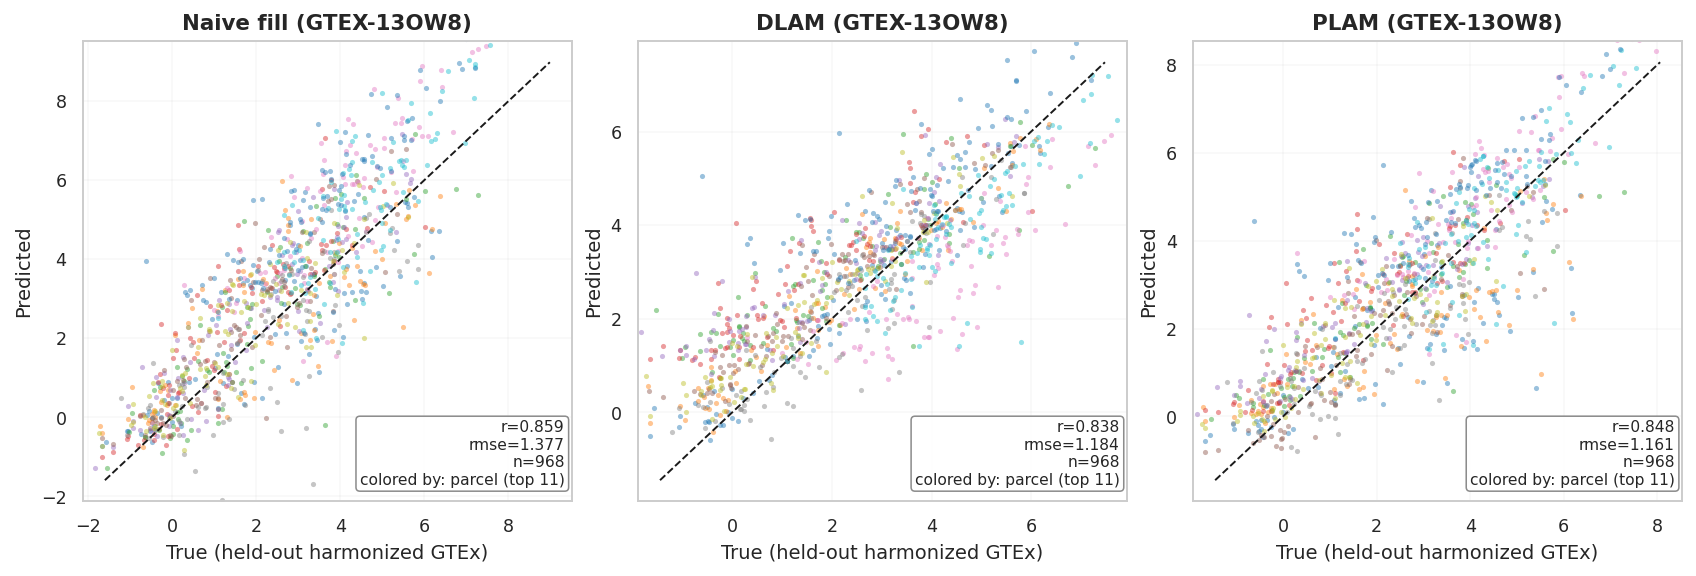

In [17]:
# HVG-only evaluation (models still from all-genes cache), colored by parcel
fig, axes, _ = plot_single_subject_scatter_triplet(
    cfg=CFG,
    subject_id=SUBJECT_ID,
    color_by='parcel',
    top_n=11,
    eval_gene_mode='hvg',
    figsize=(12.0, 4.0),
)


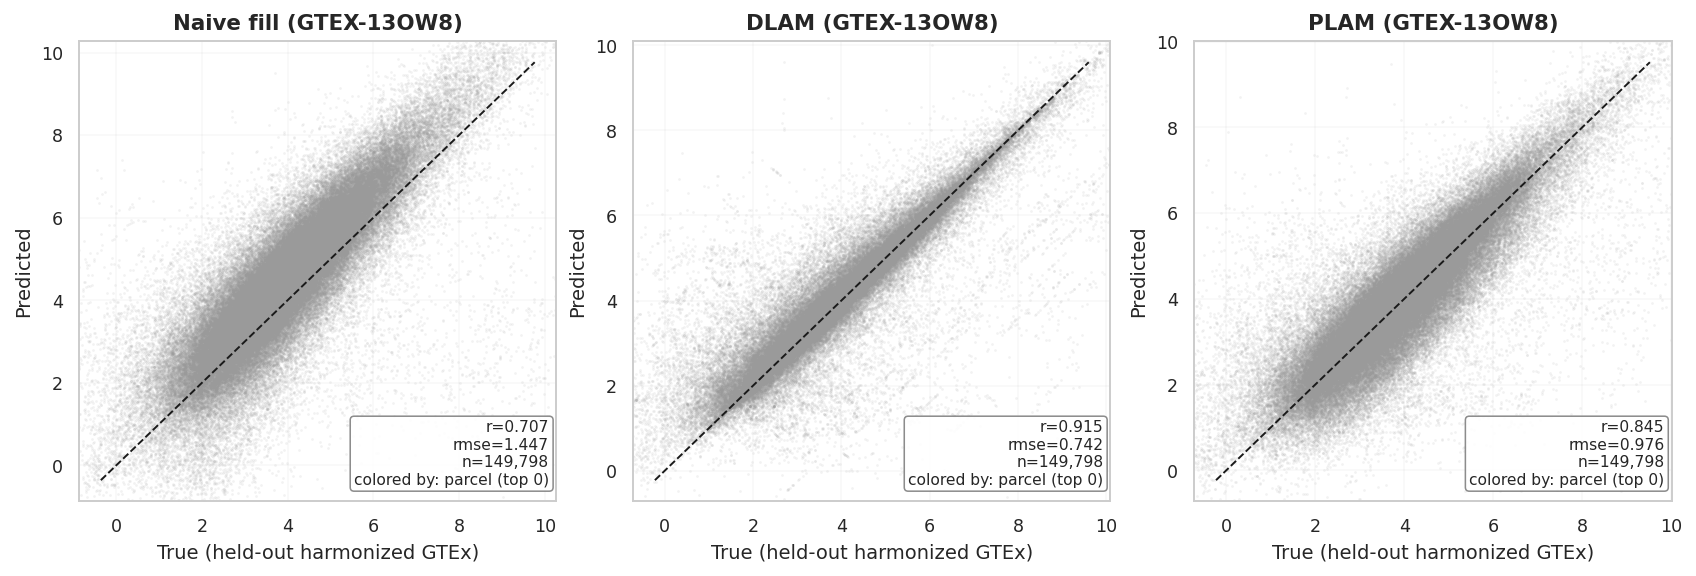

In [29]:
# All-genes evaluation, colored by parcel
fig, axes, _ = plot_single_subject_scatter_triplet(
    cfg=CFG,
    subject_id=SUBJECT_ID,
    color_by='parcel',
    top_n=0,
    eval_gene_mode='all',
    figsize=(12.0, 4.0),
)


## Cohort Summaries (HVG-stratified evaluation from all-genes fit caches)


In [49]:
import src.eval_utils.results_eda
importlib.reload(src.eval_utils.results_eda)
from src.eval_utils.results_eda import *


In [50]:
naive_df = compute_subject_metrics_from_cache_gene_subset(CFG, model='naive', eval_gene_mode='hvg')
dlam_df  = compute_subject_metrics_from_cache_gene_subset(CFG, model='dlam',  eval_gene_mode='hvg')
plam_df  = compute_subject_metrics_from_cache_gene_subset(CFG, model='plam',  eval_gene_mode='hvg')
metrics_df = pd.concat([naive_df, dlam_df, plam_df], ignore_index=True)

print('rows:', len(metrics_df), '| subjects:', metrics_df['subject'].nunique())
display(metrics_df.head(5))


rows: 939 | subjects: 313


,subject,model,coverage,n_loro_parcels,n_eval_genes,n_total_genes,eval_gene_mode,n_points,pearson_r,rmse
0,GTEX-11ZU8,naive,5,5,88,13618,hvg,440,0.866813,1.552024
1,GTEX-131XW,naive,5,5,88,13618,hvg,440,0.833423,1.882198
2,GTEX-13CZV,naive,5,5,88,13618,hvg,440,0.852467,1.456364
3,GTEX-13NZA,naive,5,5,88,13618,hvg,440,0.824057,1.671875
4,GTEX-145MG,naive,5,5,88,13618,hvg,440,0.814112,1.665782


,model,pearson_mean,pearson_std,rmse_mean,rmse_std,n_subjects,pearson_err,rmse_err
0,naive,0.811316,0.039957,1.485770,0.219263,313,0.039957,0.219263
1,dlam,0.712077,0.117338,1.707058,0.543972,313,0.117338,0.543972
2,plam,0.784745,0.053571,1.479311,0.299545,313,0.053571,0.299545


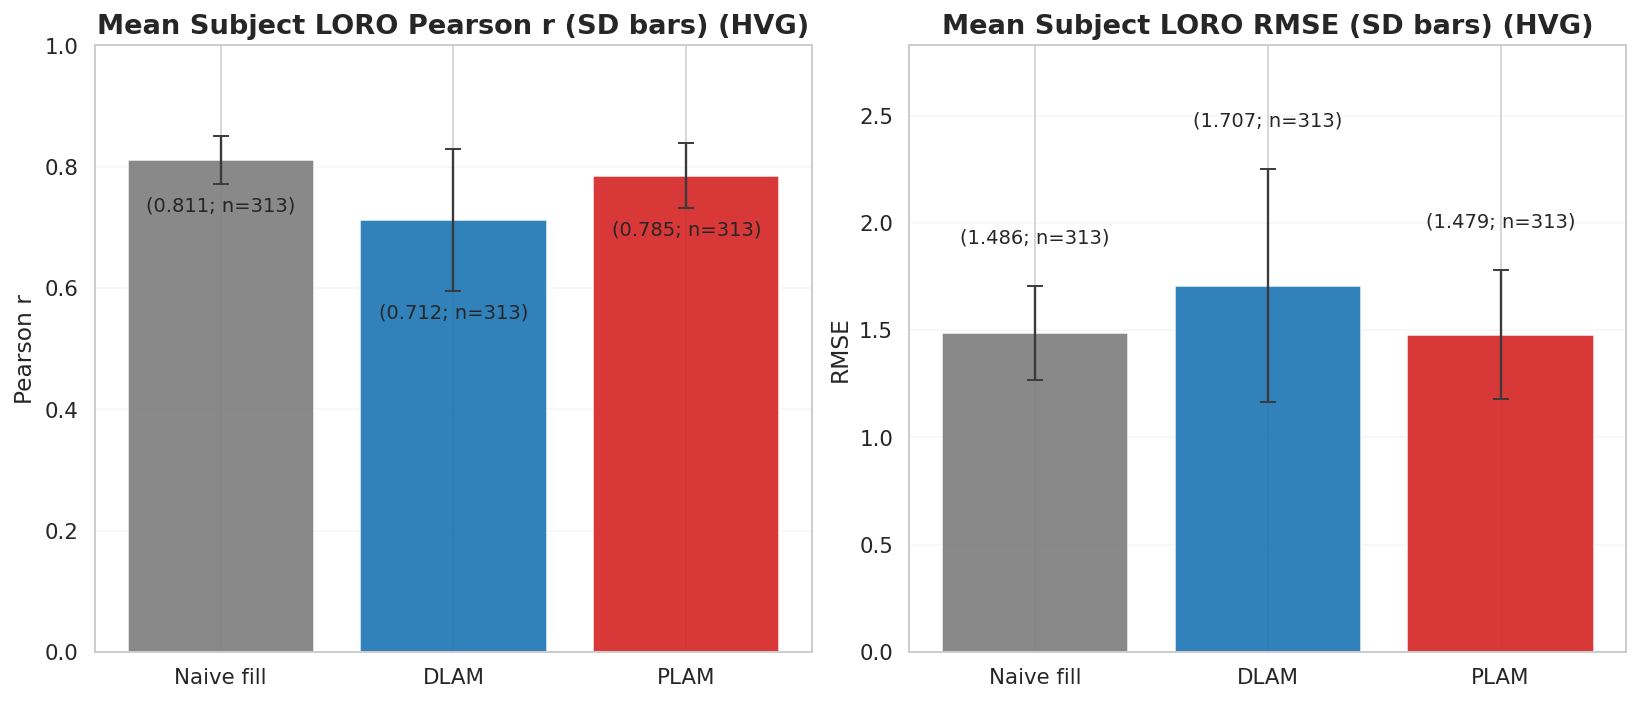

In [53]:
fig, axes, summary_df = plot_loro_subject_summary_bars(metrics_df, figsize=(11.6, 4.9), use_sem=False)
display(summary_df)


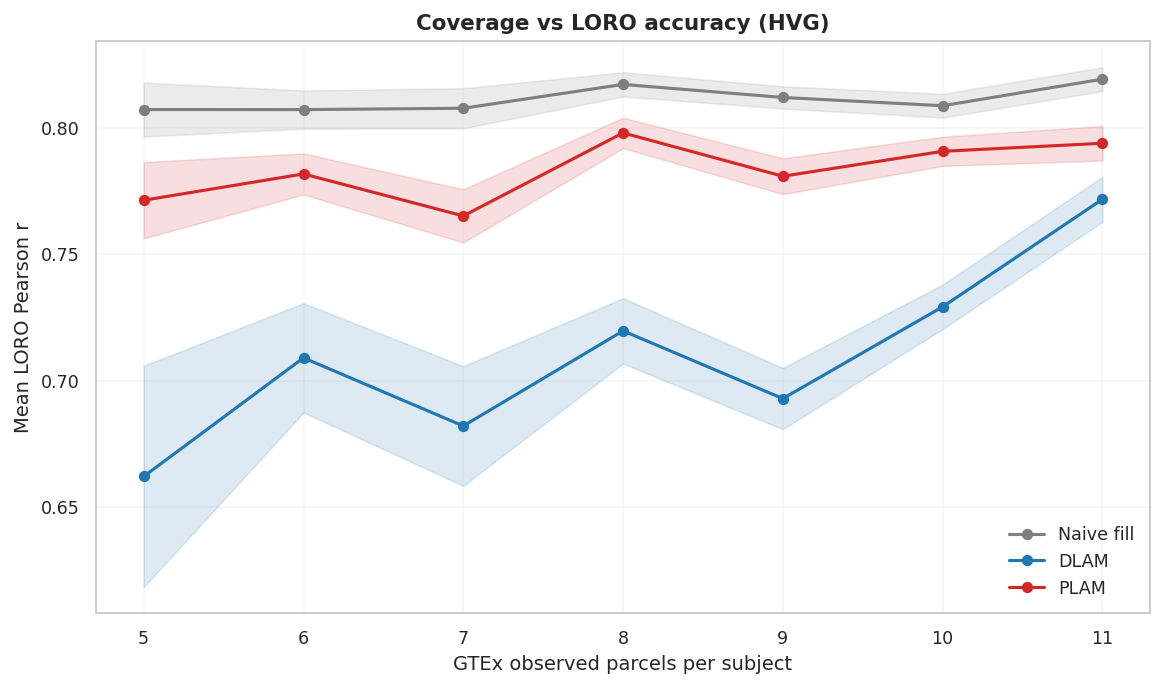

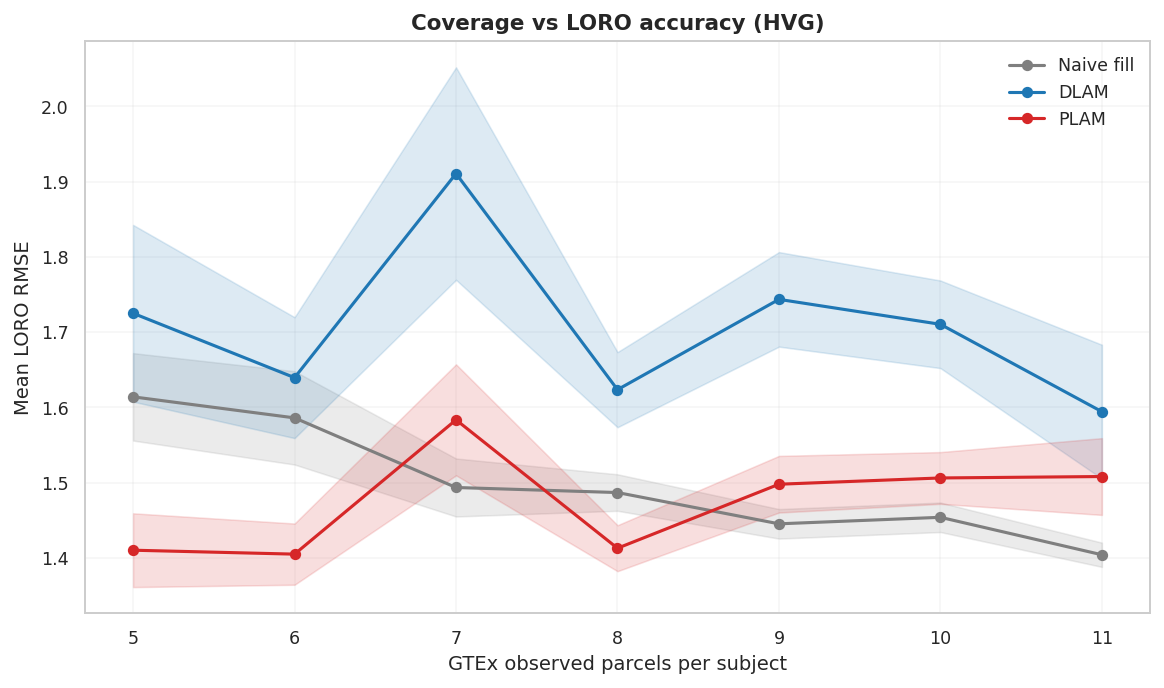

In [54]:
fig, ax = plot_coverage_vs_accuracy(metrics_df, metric='pearson_r', figsize=(8.2, 4.8))
fig, ax = plot_coverage_vs_accuracy(metrics_df, metric='rmse', figsize=(8.2, 4.8))
